## 3. Awe Phenotypes & Demographic Clustering

### Question: Can we identify distinct "Awe Phenotypes" based on the interaction between upbringing (env_growth), current worldview, and spiritual triggers?
Why it’s essential: This satisfies the sponsors' interest in Cluster Analysis. It moves beyond individual traits to see if there are "groups" of people (e.g., the "Nature-Centric Secularist" vs. the "Spiritual Traditionalist") and whether certain groups are more likely to possess the SPARK trait.


In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('cleaned_responses_update.xlsx', sheet_name='cleanedAweExperienceSurveyRespo')

In [4]:
df['chills_ability'].value_counts()

chills_ability
0.0    68
1.0    31
Name: count, dtype: int64

In [5]:
df.columns

Index(['timestamp', 'age_range', 'env_growth', 'worldview', 'activity_primary',
       'regular_practices', 'household_size', 'gender_assigned',
       'gender_identity', 'edu_level', 'income_bracket', 'socioec_status',
       'college_name', 'awe_scale_1', 'awe_scale_2', 'awe_scale_3',
       'awe_scale_4', 'awe_scale_5', 'awe_scale_6', 'awe_scale_7',
       'awe_scale_8', 'awe_scale_9', 'awe_scale_10', 'awe_scale_11',
       'awe_scale_12', 'control', 'trigger_moved_1', 'trigger_moved_2',
       'trigger_moved_3', 'trigger_moved_4', 'trigger_moved_5',
       'trigger_moved_6', 'trigger_moved_7', 'trigger_moved_8',
       'trigger_moved_9', 'trigger_moved_10', 'trigger_phys_1',
       'trigger_phys_2', 'trigger_phys_3', 'trigger_phys_4', 'trigger_phys_5',
       'trigger_phys_6', 'trigger_phys_7', 'trigger_phys_8', 'trigger_phys_9',
       'trigger_interpersonal_1', 'trigger_interpersonal_2',
       'trigger_interpersonal_3', 'trigger_interpersonal_4',
       'trigger_interpersonal_5'

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.impute import SimpleImputer

In [7]:
df['income_bracket'].values

array(['0-50K', '0-50K', '0-50K', '0-50K', '0-50K', '0-50K', '0-50K',
       '0-50K', '0-50K', '100K+', '0-50K', '0-50K', '0-50K', '0-50K',
       '70-90K', '0-50K', '100K+', '0-50K', '100K+', '50-70K', '100K+',
       '0-50K', '50-70K', '0-50K', '70-90K', '0-50K', '50-70K', '0-50K',
       '0-50K', '0-50K', '0-50K', '50-70K', '0-50K', '70-90K', '0-50K',
       '70-90K', '70-90K', '0-50K', '100K+', '70-90K', '70-90K', '0-50K',
       '0-50K', '0-50K', '70-90K', '100K+', '0-50K', '0-50K', '0-50K',
       '0-50K', '0-50K', '0-50K', '0-50K', '0-50K', '0-50K', '0-50K',
       '0-50K', '0-50K', '0-50K', '100K+', '0-50K', '0-50K', '50-70K',
       '0-50K', '0-50K', '0-50K', '0-50K', '0-50K', '100K+', '0-50K',
       '0-50K', '0-50K', '100K+', '0-50K', '50-70K', '0-50K', '0-50K',
       '0-50K', '50-70K', '0-50K', '0-50K', nan, '70-90K', '0-50K',
       '50-70K', '70-90K', '0-50K', '0-50K', '50-70K', '0-50K', '50-70K',
       '0-50K', '0-50K', '50-70K', '50-70K', '100K+', '50-70K', '70-90K',


In [8]:
df = df.dropna(subset=['income_bracket']).reset_index(drop=True)

In [9]:
df['income_bracket'].values

array(['0-50K', '0-50K', '0-50K', '0-50K', '0-50K', '0-50K', '0-50K',
       '0-50K', '0-50K', '100K+', '0-50K', '0-50K', '0-50K', '0-50K',
       '70-90K', '0-50K', '100K+', '0-50K', '100K+', '50-70K', '100K+',
       '0-50K', '50-70K', '0-50K', '70-90K', '0-50K', '50-70K', '0-50K',
       '0-50K', '0-50K', '0-50K', '50-70K', '0-50K', '70-90K', '0-50K',
       '70-90K', '70-90K', '0-50K', '100K+', '70-90K', '70-90K', '0-50K',
       '0-50K', '0-50K', '70-90K', '100K+', '0-50K', '0-50K', '0-50K',
       '0-50K', '0-50K', '0-50K', '0-50K', '0-50K', '0-50K', '0-50K',
       '0-50K', '0-50K', '0-50K', '100K+', '0-50K', '0-50K', '50-70K',
       '0-50K', '0-50K', '0-50K', '0-50K', '0-50K', '100K+', '0-50K',
       '0-50K', '0-50K', '100K+', '0-50K', '50-70K', '0-50K', '0-50K',
       '0-50K', '50-70K', '0-50K', '0-50K', '70-90K', '0-50K', '50-70K',
       '70-90K', '0-50K', '0-50K', '50-70K', '0-50K', '50-70K', '0-50K',
       '0-50K', '50-70K', '50-70K', '100K+', '50-70K', '70-90K', '70-9

(97, 71)
(84, 71)
age_range: [1 3 0 4 2 5]
edu_level: [2 0 3 1]
income_bracket: [0. 3. 1.]
socioec_status: [3 2 0 1]


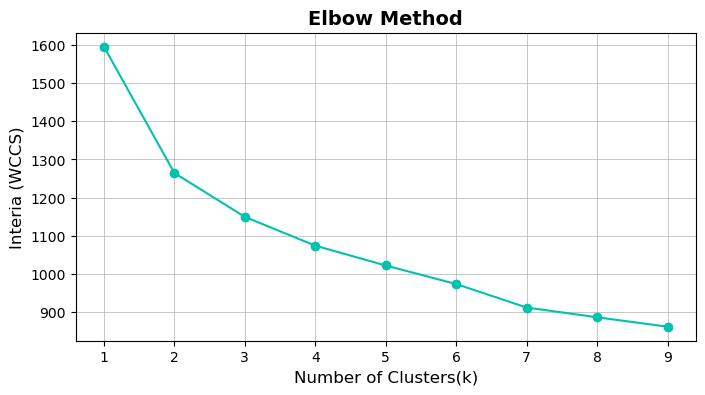

In [10]:
clean_df = df.dropna(subset=['age_range', 'env_growth', 'worldview', 'activity_primary', 'gender_assigned', 'edu_level', 'income_bracket',
                             'socioec_status', 'trigger_interpersonal_4', 'trigger_interpersonal_5', 'trigger_spiritual_1', 
                             'trigger_spiritual_2', 'trigger_spiritual_3', 'trigger_spiritual_4', 'trigger_interpersonal_9', 'trigger_spiritual_5', 
                             'trigger_spiritual_6','trigger_spiritual_7', 'trigger_spiritual_8', 'chills_ability']).reset_index(drop=True)

print(clean_df.shape)

#encoding
age_order = ['17-18', '19-21', '22-24', '25-30', '31-37', '38+']
edu_order = ['High school Diploma/GED', 'Associates Degree', 'Undergraduate', 'Graduate']
income_order = ['0-50K', '50-70K', '70-90k', '100K+']
socioec_order = ['Poverty', 'Low middle class', 'Middle class','Upper middle class']

clean_df['age_range'] = clean_df['age_range'].map({v: i for i, v in enumerate(age_order)})
clean_df['edu_level'] = clean_df['edu_level'].map({v: i for i, v in enumerate(edu_order)})
clean_df['income_bracket'] = clean_df['income_bracket'].map({v: i for i, v in enumerate(income_order)})
clean_df['socioec_status'] = clean_df['socioec_status'].map({v: i for i, v in enumerate(socioec_order)})

for col in ['env_growth', 'worldview', 'activity_primary', 'gender_assigned']:
    clean_df[col] = LabelEncoder().fit_transform(clean_df[col].astype(str))

#drop any NaNs introduced by mapping BEFORE building feature groups
clean_df = clean_df.dropna(subset=['age_range', 'edu_level', 'income_bracket', 'socioec_status']).reset_index(drop=True)

print(clean_df.shape)

#Building the feature groups
demo_cols = ['age_range', 'env_growth', 'worldview', 'activity_primary','gender_assigned', 'edu_level', 'income_bracket','socioec_status']

demo_columns = clean_df[demo_cols]

rel_self_trans = clean_df[['trigger_interpersonal_4', 'trigger_interpersonal_5', 'trigger_spiritual_1',
                     'trigger_spiritual_2', 'trigger_spiritual_3', 'trigger_spiritual_4']]

bel_strength = clean_df[['trigger_interpersonal_9', 'trigger_spiritual_5', 'trigger_spiritual_6',
                  'trigger_spiritual_7', 'trigger_spiritual_8']]

features = pd.concat([demo_columns, rel_self_trans, bel_strength], axis=1)

#scaling the data
scaler = StandardScaler()
X = scaler.fit_transform(features)


for col in ['age_range', 'edu_level', 'income_bracket', 'socioec_status']:
    print(f"{col}:", clean_df[col].unique())

#elbow method 
inertias = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

#plotting the elbow methods graph
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='#00C2AE')
plt.xlabel('Number of Clusters(k)', fontsize=12)
plt.ylabel('Interia (WCCS)', fontsize=12)
plt.title('Elbow Method', fontweight='bold', fontsize=14)
plt.grid(linewidth=0.5)
plt.show()
    


In [11]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=12, n_init=10)
labels = kmeans.fit_predict(X)

print(silhouette_score(X, labels))

0.13143164755106268


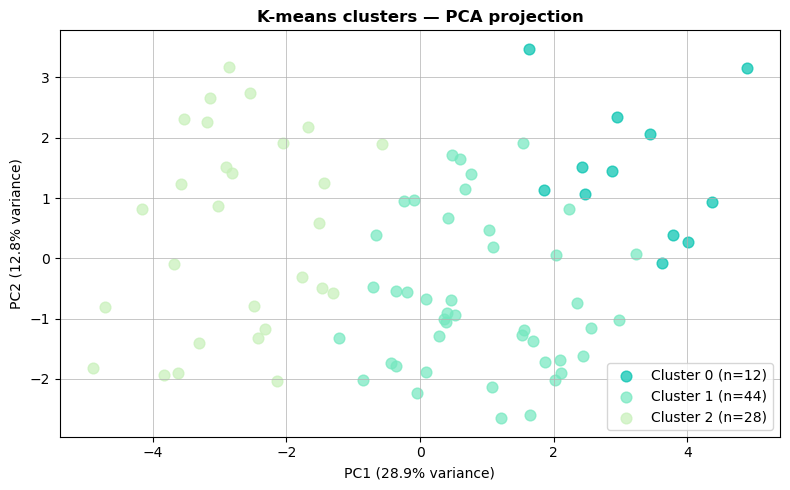

In [12]:
#The silhouette scores shows that there is little meaningful clustering. 
from sklearn.decomposition import PCA

clean_df['cluster'] = labels

pca = PCA(n_components=2, random_state=22)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 5))
colors = {0: '#00C2AE', 1:'#74E8BF', 2:'#C7F0B9'}
for c in [0, 1, 2,]:
    mask = labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                label=f'Cluster {c} (n={mask.sum()})', 
                color = colors[c], alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-means clusters — PCA projection', fontweight='bold', fontsize=12)
plt.legend()
plt.tight_layout()
plt.grid(linewidth=0.5)
plt.show()    



In [13]:
print(clean_df.groupby('cluster')['chills_ability'].mean().round(2))

cluster
0    0.25
1    0.27
2    0.36
Name: chills_ability, dtype: float64


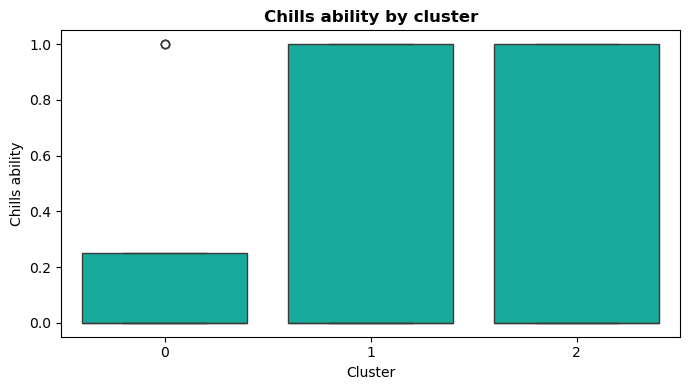

In [14]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=clean_df, x='cluster', y='chills_ability', color='#00C2AE')
plt.title('Chills ability by cluster', fontsize=12, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Chills ability')
plt.tight_layout()
plt.show()

In [15]:
print(clean_df.groupby('cluster')['chills_ability'].value_counts().unstack().fillna(0))

chills_ability  0.0  1.0
cluster                 
0                 9    3
1                32   12
2                18   10


## Running a clustering analysis with only the people who could induce chills

The clustering analysis is going to analyze the demographic data and spiritual data: 

including the following questions: 

1. How strongly do you believe in meaningful coincidences?
2. Do you believe in universal energy such as chakras, kundalini, etc?
3. How strongly do you believe in God or divine being?
4. Do you believe in souls, spirits, or unseen beings?
5. How strongly do you believe in karma or moral causation? 

In [18]:
clean_df.columns

Index(['timestamp', 'age_range', 'env_growth', 'worldview', 'activity_primary',
       'regular_practices', 'household_size', 'gender_assigned',
       'gender_identity', 'edu_level', 'income_bracket', 'socioec_status',
       'college_name', 'awe_scale_1', 'awe_scale_2', 'awe_scale_3',
       'awe_scale_4', 'awe_scale_5', 'awe_scale_6', 'awe_scale_7',
       'awe_scale_8', 'awe_scale_9', 'awe_scale_10', 'awe_scale_11',
       'awe_scale_12', 'control', 'trigger_moved_1', 'trigger_moved_2',
       'trigger_moved_3', 'trigger_moved_4', 'trigger_moved_5',
       'trigger_moved_6', 'trigger_moved_7', 'trigger_moved_8',
       'trigger_moved_9', 'trigger_moved_10', 'trigger_phys_1',
       'trigger_phys_2', 'trigger_phys_3', 'trigger_phys_4', 'trigger_phys_5',
       'trigger_phys_6', 'trigger_phys_7', 'trigger_phys_8', 'trigger_phys_9',
       'trigger_interpersonal_1', 'trigger_interpersonal_2',
       'trigger_interpersonal_3', 'trigger_interpersonal_4',
       'trigger_interpersonal_5'

In [19]:
chill_positive = clean_df[clean_df['chills_ability_text'] == 'Yes']

chill_positive.shape

(25, 72)

In [20]:
#Pulling all demographic data for subjects who would induce chills

chills_data = chill_positive[['age_range', 'env_growth', 'worldview', 'activity_primary', 'gender_assigned',
       'gender_identity', 'edu_level', 'income_bracket', 'socioec_status']]

#chills_data.shape

#chills_data

In [21]:
chills_data = chill_positive[['age_range', 'env_growth', 'worldview', 'activity_primary', 'gender_assigned',
       'gender_identity', 'edu_level', 'income_bracket', 'socioec_status']]

spiritual_data = chill_positive[['trigger_interpersonal_9', 'trigger_spiritual_5', 
                                 'trigger_spiritual_6','trigger_spiritual_7', 'trigger_spiritual_8']]

spiritual_data = spiritual_data.dropna(subset=('trigger_interpersonal_9', 'trigger_spiritual_5', 
                                 'trigger_spiritual_6','trigger_spiritual_7', 'trigger_spiritual_8'))

chill_spirit_data = pd.concat([chills_data.reset_index(drop=True), spiritual_data.reset_index(drop=True)], axis=1)

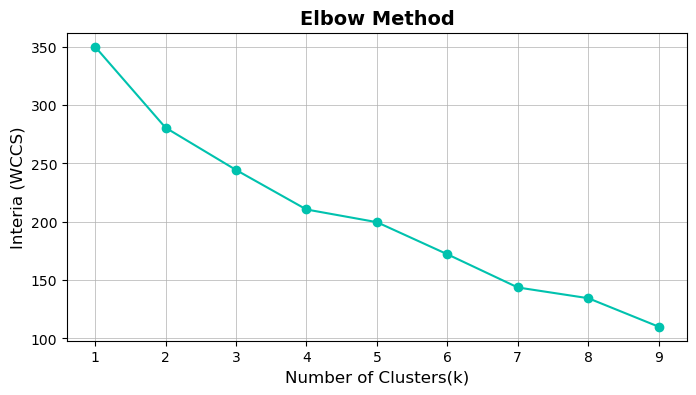

In [22]:
chill_spirit_data['gender_identity'] = LabelEncoder().fit_transform(chill_spirit_data['gender_identity'])

chill_spirit_data = chill_spirit_data.dropna(subset=('age_range', 'env_growth', 'worldview', 'activity_primary', 'gender_assigned',
       'gender_identity', 'edu_level', 'income_bracket', 'socioec_status')).reset_index(drop=True)

#scaling the data
scaler = StandardScaler()
X = scaler.fit_transform(chill_spirit_data)

#elbow method 
inertias = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

#plotting the elbow methods graph
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='#00C2AE')
plt.xlabel('Number of Clusters(k)', fontsize=12)
plt.ylabel('Interia (WCCS)', fontsize=12)
plt.title('Elbow Method', fontweight='bold', fontsize=14)
plt.grid(linewidth=0.5)
plt.show()
    

In [23]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=12, n_init=10)
labels = kmeans.fit_predict(X)

print(silhouette_score(X, labels))

0.12958592169008917


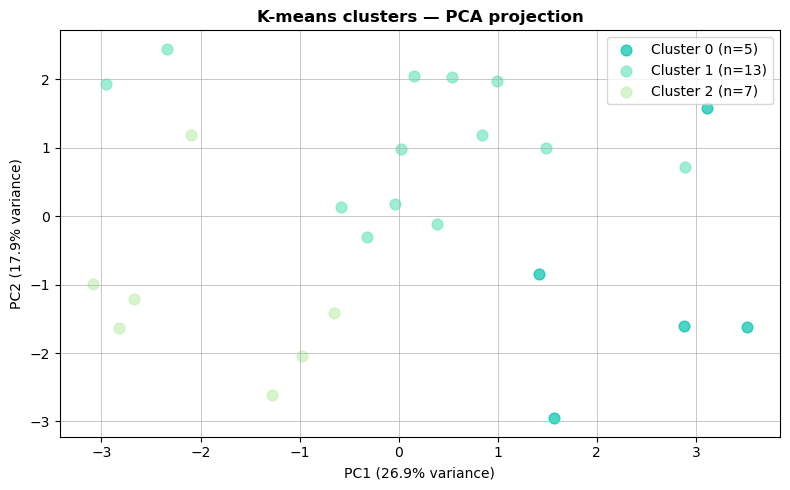

In [24]:
#The silhouette scores shows that there is little meaningful clustering. 
from sklearn.decomposition import PCA

chill_spirit_data['cluster'] = labels

pca = PCA(n_components=2, random_state=22)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 5))
colors = {0: '#00C2AE', 1:'#74E8BF', 2:'#C7F0B9'}
for c in [0, 1, 2,]:
    mask = labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                label=f'Cluster {c} (n={mask.sum()})', 
                color = colors[c], alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-means clusters — PCA projection', fontweight='bold', fontsize=12)
plt.legend()
plt.tight_layout()
plt.grid(linewidth=0.5)
plt.show()    



In [25]:
chill_spirit_data

,age_range,env_growth,worldview,activity_primary,gender_assigned,gender_identity,edu_level,income_bracket,socioec_status,trigger_interpersonal_9,trigger_spiritual_5,trigger_spiritual_6,trigger_spiritual_7,trigger_spiritual_8,cluster
0,1,0,1,2,0,0,0,0.0,3,3.0,2,1,3,3.0,1
1,1,3,4,4,0,0,2,0.0,2,3.0,4,5,5,5.0,0
2,3,3,1,3,1,2,0,0.0,2,1.0,1,1,1,2.0,1
3,3,3,1,4,1,1,2,0.0,3,3.0,1,1,1,2.0,2
4,1,3,3,3,1,1,0,3.0,3,2.0,1,5,4,1.0,1
5,3,3,0,4,0,0,3,0.0,2,3.0,1,1,1,1.0,2
6,3,1,4,0,1,1,2,1.0,3,3.0,2,2,2,3.0,1
7,3,3,0,4,0,0,3,0.0,2,2.0,1,2,2,2.0,2
8,5,3,3,4,0,0,3,1.0,2,3.0,1,4,4,1.0,2
9,4,3,0,4,0,0,2,0.0,0,3.0,2,2,3,3.0,2


In [26]:
chill_spirit_data.groupby('cluster').mean()

,age_range,env_growth,worldview,activity_primary,gender_assigned,gender_identity,edu_level,income_bracket,socioec_status,trigger_interpersonal_9,trigger_spiritual_5,trigger_spiritual_6,trigger_spiritual_7,trigger_spiritual_8
cluster,,,,,,,,,,,,,,
0,1.800000,1.600000,3.000000,2.800000,0.400000,0.400000,1.800000,0.400000,1.200000,3.800000,3.200000,4.400000,4.400000,4.400000
1,1.230769,2.384615,2.307692,2.461538,0.384615,0.615385,0.307692,0.384615,2.307692,2.846154,2.076923,2.230769,2.538462,2.538462
2,3.428571,3.000000,0.857143,4.000000,0.142857,0.142857,2.571429,0.571429,1.714286,2.714286,1.285714,2.000000,2.285714,2.000000


Breakdown of the three clusters for the participants who can induce chills: 


### Cluster 1
1. Age range 1.8 signifies that the majority of this population was between 17-24. But the average participant age within this cluster is the middle age range closer to the age range for cluster 2. The most common value for age was 17-18. 
2. This cluster has a larger number of male participants and the highest averages for the spiritual data relating to the construct Belief Strength Ranking. The range was between 3.2-4.4.
3. The most common worldview was Religious/Theistic. 
4. Most common environmental growth was near leage bodies of water/nature. 
5. This cluster had the lowest socioeconmic status.
6. Education level was in the mid range.
7. Income bracket was very similat to cluster 2, nearly the same with a 0.02 difference. 

### Cluster 2
1. Mid range values between 2.077 - 2.846 for the spiritual questions.
2. The age range was lower than cluster one with the majority of the ages being between 17-21. This was the young average age range of the clusters. The most common value was 17-18.
3. The most common environmental growth area was rural/remote. 
4. Mid ranges for spritual awareness.
5. The most common worldview was Religious/Theistic. 
6. Had the highest socioeconomic class.
7. Lowest Education level.
8. Income bracket was very similat to cluster 1, nearly the same with a 0.02 difference. 

### Cluster 3
1. The was the oldest age range of the clusters and with an average of 3.42 it would be about 22-30.
2. This had the lowest spiritual awareness means potentially showing that the participants within this age group had less spiritual exposure or awareness.
3. The most common environmental growth area was rural/remote.
4. The most common worldview was atheist/naturalist. 
5. Socioeconomic class was right in the middle of cluster 1 and 2.
6. Highest Education level.
7. Income bracket was the highest at 0.57. 

In [28]:
le = LabelEncoder()
le.fit(df['worldview'].astype(str))
print(dict(enumerate(le.classes_)))

le.fit(df['env_growth'].astype(str))
print(dict(enumerate(le.classes_)))

le.fit(df['gender_assigned'].astype(str))
print(dict(enumerate(le.classes_)))

le.fit(df['activity_primary'].astype(str))
print(dict(enumerate(le.classes_)))

{0: 'Agnostic/Secular', 1: 'Atheist/Naturalist', 2: 'Other', 3: 'Religious/Theistic', 4: 'Spiritual but not Religious'}
{0: 'Highly urban', 1: 'Near large bodies of water/Nature', 2: 'Rural/Remote', 3: 'Suburban'}
{0: 'Female', 1: 'Male', 2: 'nan'}
{0: 'Extracurricular Activities', 1: 'Social Events', 2: 'Student Clubs', 3: 'Studying', 4: 'Work'}


## Clustering the data by construct. 

Brya has already created a cluster analysis for the Absorption MODTAS and Openness to experience construct. Please refer to her code. 

### Openness to Experience Construct

In [31]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

In [43]:
open_df = df.copy()

features = ['age_range', 'env_growth', 'worldview', 'activity_primary', 
    'gender_assigned', 'edu_level', 'income_bracket', 'socioec_status', 
    'awe_scale_1',
'awe_scale_2',
'awe_scale_3',
'awe_scale_4',
'awe_scale_5']

#one hot encode the text categories
X_encoded = pd.get_dummies(open_df[features], drop_first=True)

#2. Impute (look at 5 nearest neighbors by default)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_encoded)

#3. Scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#4. Building the cluster model
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
open_df['cluster'] = kmeans.fit_predict(X_scaled)

#5. Dimensionality reduction for visualization
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
open_df['pca_1'] = pca_data[:,0]
open_df['pca_2'] = pca_data[:,1]

#6. Analysis: Identifying the Awe phenotpyes 
phenotype_profiles = open_df.groupby('cluster')[features].agg(lambda x: x.mode()[0])
phenotype_profiles = (
    open_df
    .groupby('cluster')[features]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)
phenotype_profiles.set_index('cluster', inplace=True)

print("--- Phenotype Profiles (Dominant Traits) ---")
display(phenotype_profiles.T)

--- Phenotype Profiles (Dominant Traits) ---


cluster,0,1,2
age_range,19-21,25-30,22-24
env_growth,Suburban,Suburban,Suburban
worldview,Religious/Theistic,Spiritual but not Religious,Religious/Theistic
activity_primary,Studying,Work,Work
gender_assigned,Female,Female,Female
edu_level,High school Diploma/GED,Undergraduate,Graduate
income_bracket,0-50K,0-50K,0-50K
socioec_status,Upper middle class,Low middle class,Middle class
awe_scale_1,4,4,4
awe_scale_2,4,4,4



--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---


chills_ability,cluster,0.0,1.0
0,0,71.43,28.57
1,1,70.37,29.63
2,2,59.09,40.91


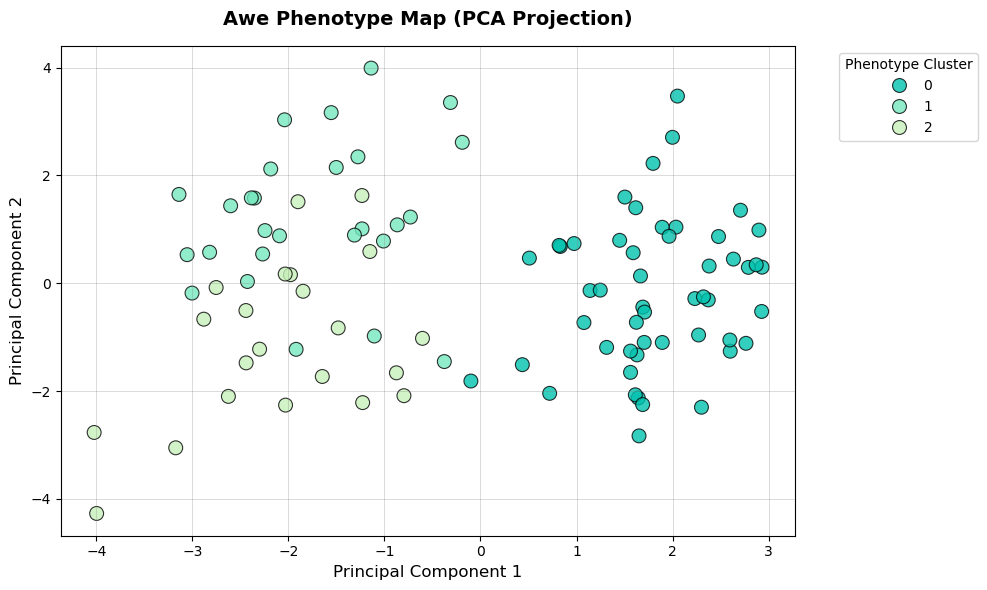

In [51]:
#7. Target Link: How does each phenotype related to the SPARK trait? 
#assuming 'chills_ability' is coded as 0/1

spark_link_df = (
    open_df
    .groupby('cluster')['chills_ability']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

# Round percentages
spark_link_df = spark_link_df.round(2)

# Reset index for cleaner table formatting
spark_link_df = spark_link_df.reset_index()

print("\n--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---")
display(spark_link_df)

#8. Visualize the Phenotype Map
pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=open_df, x='pca_1', y='pca_2', hue='cluster', palette=pheno_colors, edgecolor='black', alpha=0.8, s=100)

# Titles - bolded, fontsize 14
plt.title('Awe Phenotype Map (PCA Projection)', fontsize=14, fontweight='bold', pad=15)

# Axis Labels - fontsize 12
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Grid Lines - color grey, weight 0.1-0.4
# Note: linewidth (lw) set to 0.4 for a subtle but visible look
plt.grid(True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)

# Move legend to the side so it doesn't block the grid
plt.legend(title='Phenotype Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Absorption MODTAS Construct

In [56]:
absorption_df = df.copy()

features = ['age_range', 'env_growth', 'worldview', 'activity_primary', 
    'gender_assigned', 'edu_level', 'income_bracket', 'socioec_status', 
'awe_scale_6',
'awe_scale_7',
'awe_scale_8',
'awe_scale_9',
'awe_scale_10',
'awe_scale_11',
'awe_scale_12']

#one hot encode the text categories
X_encoded = pd.get_dummies(absorption_df[features], drop_first=True)

#2. Impute (look at 5 nearest neighbors by default)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_encoded)

#3. Scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#4. Building the cluster model
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
absorption_df['cluster'] = kmeans.fit_predict(X_scaled)

#5. Dimensionality reduction for visualization
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
absorption_df['pca_1'] = pca_data[:,0]
absorption_df['pca_2'] = pca_data[:,1]

#6. Analysis: Identifying the Awe phenotpyes 
phenotype_profiles = absorption_df.groupby('cluster')[features].agg(lambda x: x.mode()[0])
phenotype_profiles = (
    absorption_df
    .groupby('cluster')[features]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)
phenotype_profiles.set_index('cluster', inplace=True)

print("--- Phenotype Profiles (Dominant Traits) ---")
display(phenotype_profiles.T)

--- Phenotype Profiles (Dominant Traits) ---


cluster,0,1,2
age_range,25-30,19-21,19-21
env_growth,Suburban,Suburban,Suburban
worldview,Spiritual but not Religious,Atheist/Naturalist,Religious/Theistic
activity_primary,Work,Studying,Studying
gender_assigned,Female,Female,Female
edu_level,Undergraduate,High school Diploma/GED,High school Diploma/GED
income_bracket,0-50K,0-50K,0-50K
socioec_status,Low middle class,Upper middle class,Middle class
awe_scale_6,3,3,2
awe_scale_7,4,4,3



--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---


chills_ability,cluster,0.0,1.0
0,0,67.50,32.50
1,1,67.86,32.14
2,2,70.00,30.00


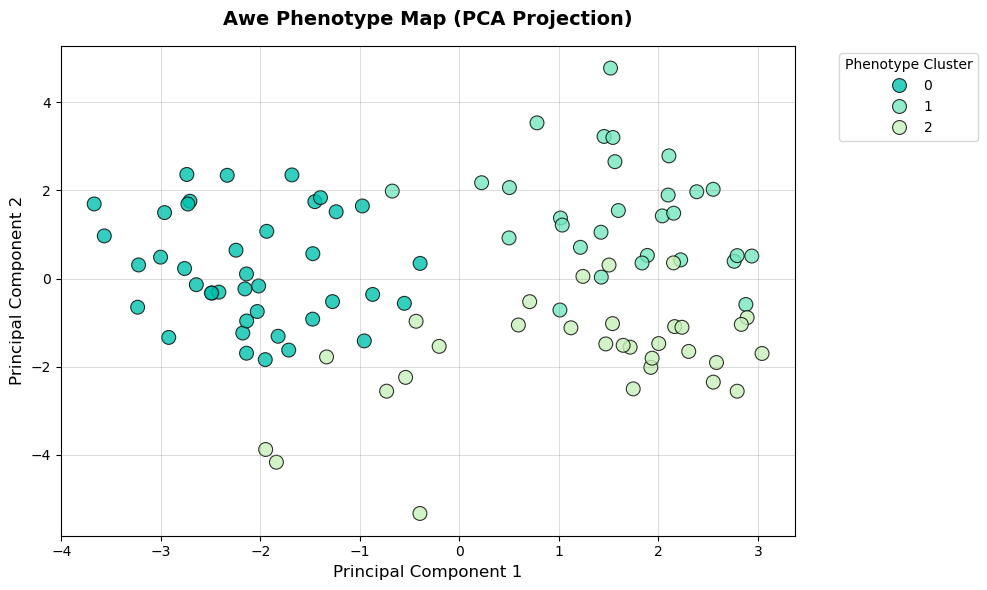

In [58]:
#7. Target Link: How does each phenotype related to the SPARK trait? 
#assuming 'chills_ability' is coded as 0/1

spark_link_df = (
    absorption_df
    .groupby('cluster')['chills_ability']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

# Round percentages
spark_link_df = spark_link_df.round(2)

# Reset index for cleaner table formatting
spark_link_df = spark_link_df.reset_index()

print("\n--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---")
display(spark_link_df)

#8. Visualize the Phenotype Map
pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=absorption_df, x='pca_1', y='pca_2', hue='cluster', palette=pheno_colors, edgecolor='black', alpha=0.8, s=100)

# Titles - bolded, fontsize 14
plt.title('Awe Phenotype Map (PCA Projection)', fontsize=14, fontweight='bold', pad=15)

# Axis Labels - fontsize 12
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Grid Lines - color grey, weight 0.1-0.4
# Note: linewidth (lw) set to 0.4 for a subtle but visible look
plt.grid(True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)

# Move legend to the side so it doesn't block the grid
plt.legend(title='Phenotype Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Kama Muta (Being Moved) Construct

In [63]:
km_df = df.copy()

features = ['age_range', 'env_growth', 'worldview', 'activity_primary', 
    'gender_assigned', 'edu_level', 'income_bracket', 'socioec_status', 
'trigger_moved_1',
'trigger_moved_2',
'trigger_moved_3',
'trigger_moved_4',
'trigger_moved_5']

#one hot encode the text categories
X_encoded = pd.get_dummies(km_df[features], drop_first=True)

#2. Impute (look at 5 nearest neighbors by default)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_encoded)

#3. Scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#4. Building the cluster model
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
km_df['cluster'] = kmeans.fit_predict(X_scaled)

#5. Dimensionality reduction for visualization
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
km_df['pca_1'] = pca_data[:,0]
km_df['pca_2'] = pca_data[:,1]

#6. Analysis: Identifying the Awe phenotpyes 
phenotype_profiles = km_df.groupby('cluster')[features].agg(lambda x: x.mode()[0])
phenotype_profiles = (
    km_df
    .groupby('cluster')[features]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)
phenotype_profiles.set_index('cluster', inplace=True)

print("--- Phenotype Profiles (Dominant Traits) ---")
display(phenotype_profiles.T)

--- Phenotype Profiles (Dominant Traits) ---


cluster,0,1,2
age_range,31-37,25-30,19-21
env_growth,Suburban,Suburban,Suburban
worldview,Spiritual but not Religious,Spiritual but not Religious,Religious/Theistic
activity_primary,Work,Work,Studying
gender_assigned,Female,Female,Female
edu_level,Undergraduate,Undergraduate,High school Diploma/GED
income_bracket,0-50K,0-50K,0-50K
socioec_status,Middle class,Low middle class,Upper middle class
trigger_moved_1,4.0,4.0,4.0
trigger_moved_2,5,4,4



--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---


chills_ability,cluster,0.0,1.0
0,0,83.33,16.67
1,1,61.90,38.10
2,2,72.00,28.00


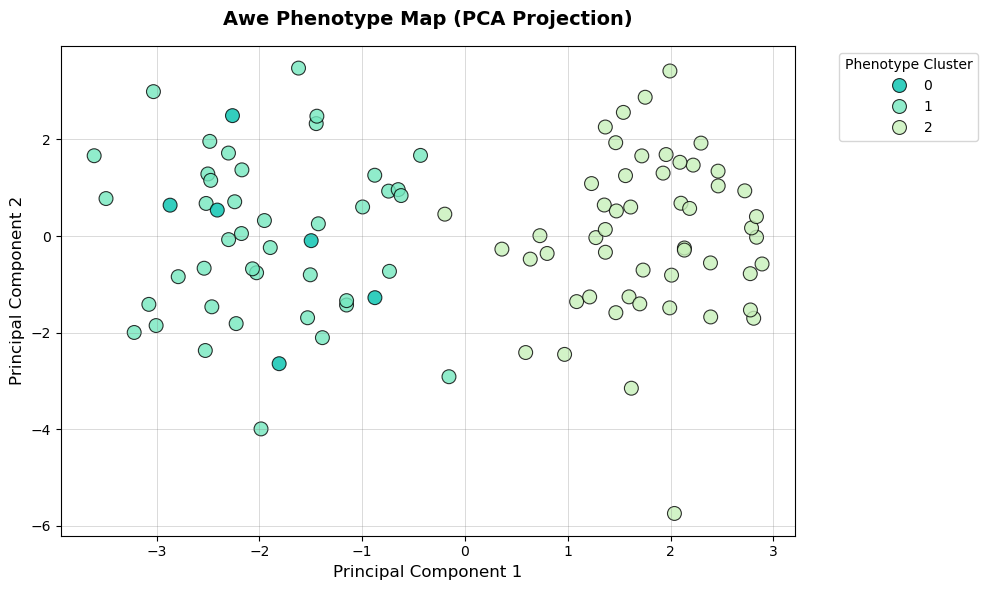

In [65]:
#7. Target Link: How does each phenotype related to the SPARK trait? 
#assuming 'chills_ability' is coded as 0/1

spark_link_df = (
    km_df
    .groupby('cluster')['chills_ability']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

# Round percentages
spark_link_df = spark_link_df.round(2)

# Reset index for cleaner table formatting
spark_link_df = spark_link_df.reset_index()

print("\n--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---")
display(spark_link_df)

#8. Visualize the Phenotype Map
pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=km_df, x='pca_1', y='pca_2', hue='cluster', palette=pheno_colors, edgecolor='black', alpha=0.8, s=100)

# Titles - bolded, fontsize 14
plt.title('Awe Phenotype Map (PCA Projection)', fontsize=14, fontweight='bold', pad=15)

# Axis Labels - fontsize 12
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Grid Lines - color grey, weight 0.1-0.4
# Note: linewidth (lw) set to 0.4 for a subtle but visible look
plt.grid(True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)

# Move legend to the side so it doesn't block the grid
plt.legend(title='Phenotype Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Dispositional Positive Emotions Construct

In [70]:
dispositional_df = df.copy()

features = ['age_range', 'env_growth', 'worldview', 'activity_primary', 
    'gender_assigned', 'edu_level', 'income_bracket', 'socioec_status', 
'trigger_moved_6',
'trigger_moved_7',
'trigger_moved_8',
'trigger_moved_9',
'trigger_moved_10']

#one hot encode the text categories
X_encoded = pd.get_dummies(dispositional_df[features], drop_first=True)

#2. Impute (look at 5 nearest neighbors by default)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_encoded)

#3. Scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#4. Building the cluster model
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
dispositional_df['cluster'] = kmeans.fit_predict(X_scaled)

#5. Dimensionality reduction for visualization
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
dispositional_df['pca_1'] = pca_data[:,0]
dispositional_df['pca_2'] = pca_data[:,1]

#6. Analysis: Identifying the Awe phenotpyes 
phenotype_profiles = dispositional_df.groupby('cluster')[features].agg(lambda x: x.mode()[0])
phenotype_profiles = (
    dispositional_df
    .groupby('cluster')[features]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)
phenotype_profiles.set_index('cluster', inplace=True)

print("--- Phenotype Profiles (Dominant Traits) ---")
display(phenotype_profiles.T)

--- Phenotype Profiles (Dominant Traits) ---


cluster,0,1,2
age_range,25-30,19-21,22-24
env_growth,Suburban,Suburban,Suburban
worldview,Atheist/Naturalist,Religious/Theistic,Agnostic/Secular
activity_primary,Work,Studying,Work
gender_assigned,Female,Female,Female
edu_level,Undergraduate,High school Diploma/GED,Graduate
income_bracket,0-50K,0-50K,0-50K
socioec_status,Low middle class,Upper middle class,Middle class
trigger_moved_6,3,4,4
trigger_moved_7,4,5,4



--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---


chills_ability,cluster,0.0,1.0
0,0,69.70,30.30
1,1,70.45,29.55
2,2,61.90,38.10


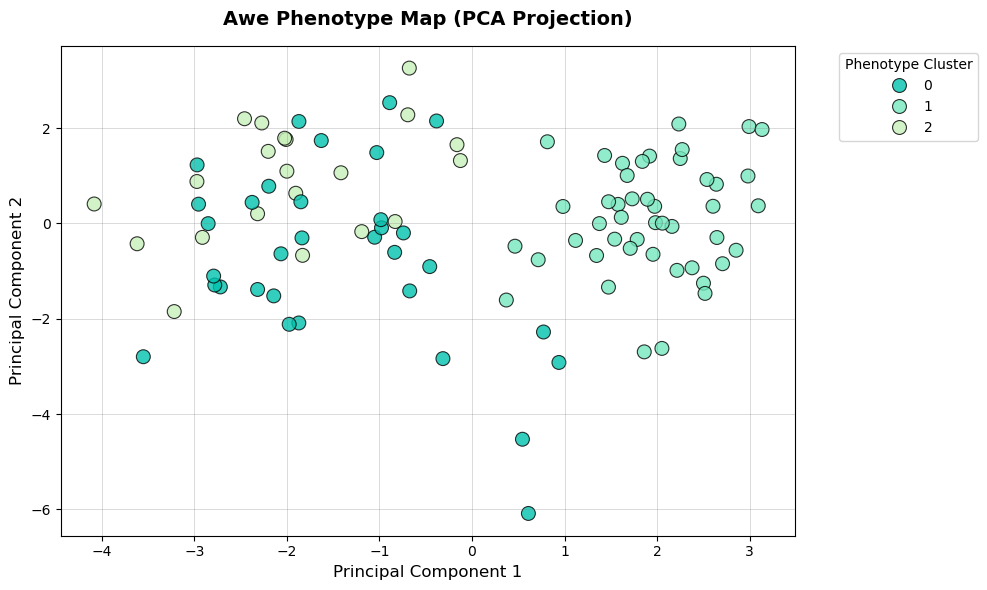

In [72]:
#7. Target Link: How does each phenotype related to the SPARK trait? 
#assuming 'chills_ability' is coded as 0/1

spark_link_df = (
    dispositional_df
    .groupby('cluster')['chills_ability']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

# Round percentages
spark_link_df = spark_link_df.round(2)

# Reset index for cleaner table formatting
spark_link_df = spark_link_df.reset_index()

print("\n--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---")
display(spark_link_df)

#8. Visualize the Phenotype Map
pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=dispositional_df, x='pca_1', y='pca_2', hue='cluster', palette=pheno_colors, edgecolor='black', alpha=0.8, s=100)

# Titles - bolded, fontsize 14
plt.title('Awe Phenotype Map (PCA Projection)', fontsize=14, fontweight='bold', pad=15)

# Axis Labels - fontsize 12
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Grid Lines - color grey, weight 0.1-0.4
# Note: linewidth (lw) set to 0.4 for a subtle but visible look
plt.grid(True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)

# Move legend to the side so it doesn't block the grid
plt.legend(title='Phenotype Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Interoceptive Awareness Construct

In [75]:
interoceptive_df = df.copy()

features = ['age_range', 'env_growth', 'worldview', 'activity_primary', 
    'gender_assigned', 'edu_level', 'income_bracket', 'socioec_status', 
'trigger_phys_1',
'trigger_phys_2',
'trigger_phys_3',
'trigger_phys_4',
'trigger_phys_5']

#one hot encode the text categories
X_encoded = pd.get_dummies(interoceptive_df[features], drop_first=True)

#2. Impute (look at 5 nearest neighbors by default)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_encoded)

#3. Scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#4. Building the cluster model
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
interoceptive_df['cluster'] = kmeans.fit_predict(X_scaled)

#5. Dimensionality reduction for visualization
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
interoceptive_df['pca_1'] = pca_data[:,0]
interoceptive_df['pca_2'] = pca_data[:,1]

#6. Analysis: Identifying the Awe phenotpyes 
phenotype_profiles = interoceptive_df.groupby('cluster')[features].agg(lambda x: x.mode()[0])
phenotype_profiles = (
    interoceptive_df
    .groupby('cluster')[features]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)
phenotype_profiles.set_index('cluster', inplace=True)

print("--- Phenotype Profiles (Dominant Traits) ---")
display(phenotype_profiles.T)

--- Phenotype Profiles (Dominant Traits) ---


cluster,0,1,2
age_range,25-30,19-21,25-30
env_growth,Suburban,Suburban,Suburban
worldview,Spiritual but not Religious,Religious/Theistic,Spiritual but not Religious
activity_primary,Work,Studying,Work
gender_assigned,Female,Female,Female
edu_level,Graduate,High school Diploma/GED,Undergraduate
income_bracket,0-50K,0-50K,0-50K
socioec_status,Middle class,Upper middle class,Low middle class
trigger_phys_1,4.0,4.0,4.0
trigger_phys_2,3.0,3.0,3.0



--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---


chills_ability,cluster,0.0,1.0
0,0,52.38,47.62
1,1,71.43,28.57
2,2,75.00,25.00


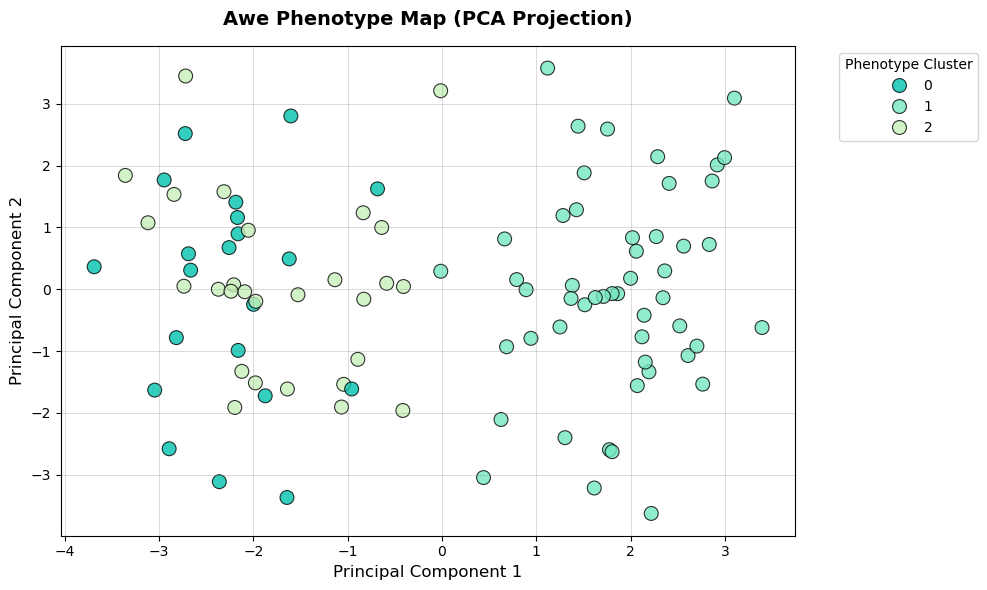

In [77]:
#7. Target Link: How does each phenotype related to the SPARK trait? 
#assuming 'chills_ability' is coded as 0/1
spark_link_df = (
    interoceptive_df
    .groupby('cluster')['chills_ability']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

# Round percentages
spark_link_df = spark_link_df.round(2)

# Reset index for cleaner table formatting
spark_link_df = spark_link_df.reset_index()

print("\n--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---")
display(spark_link_df)

#8. Visualize the Phenotype Map
pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=interoceptive_df, x='pca_1', y='pca_2', hue='cluster', palette=pheno_colors, edgecolor='black', alpha=0.8, s=100)

# Titles - bolded, fontsize 14
plt.title('Awe Phenotype Map (PCA Projection)', fontsize=14, fontweight='bold', pad=15)

# Axis Labels - fontsize 12
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Grid Lines - color grey, weight 0.1-0.4
# Note: linewidth (lw) set to 0.4 for a subtle but visible look
plt.grid(True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)

# Move legend to the side so it doesn't block the grid
plt.legend(title='Phenotype Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Mindfulness Construct

In [80]:
mindfulness_df = df.copy()

features = ['age_range', 'env_growth', 'worldview', 'activity_primary', 
    'gender_assigned', 'edu_level', 'income_bracket', 'socioec_status', 
'trigger_phys_6',
'trigger_phys_7',
'trigger_phys_8',
'trigger_phys_9',
'trigger_interpersonal_1',
'trigger_interpersonal_2',
'trigger_interpersonal_3']

#one hot encode the text categories
X_encoded = pd.get_dummies(mindfulness_df[features], drop_first=True)

#2. Impute (look at 5 nearest neighbors by default)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_encoded)

#3. Scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#4. Building the cluster model
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
mindfulness_df['cluster'] = kmeans.fit_predict(X_scaled)

#5. Dimensionality reduction for visualization
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
mindfulness_df['pca_1'] = pca_data[:,0]
mindfulness_df['pca_2'] = pca_data[:,1]

#6. Analysis: Identifying the Awe phenotpyes 
phenotype_profiles = mindfulness_df.groupby('cluster')[features].agg(lambda x: x.mode()[0])
phenotype_profiles = (
    mindfulness_df
    .groupby('cluster')[features]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)
phenotype_profiles.set_index('cluster', inplace=True)

print("--- Phenotype Profiles (Dominant Traits) ---")
display(phenotype_profiles.T)

--- Phenotype Profiles (Dominant Traits) ---


cluster,0,1,2
age_range,25-30,19-21,19-21
env_growth,Suburban,Suburban,Suburban
worldview,Spiritual but not Religious,Religious/Theistic,Atheist/Naturalist
activity_primary,Work,Studying,Studying
gender_assigned,Female,Female,Female
edu_level,Undergraduate,High school Diploma/GED,High school Diploma/GED
income_bracket,0-50K,0-50K,0-50K
socioec_status,Low middle class,Middle class,Upper middle class
trigger_phys_6,3,3,2
trigger_phys_7,3.0,3.0,2.0



--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---


chills_ability,cluster,0.0,1.0
0,0,63.83,36.17
1,1,68.75,31.25
2,2,78.95,21.05


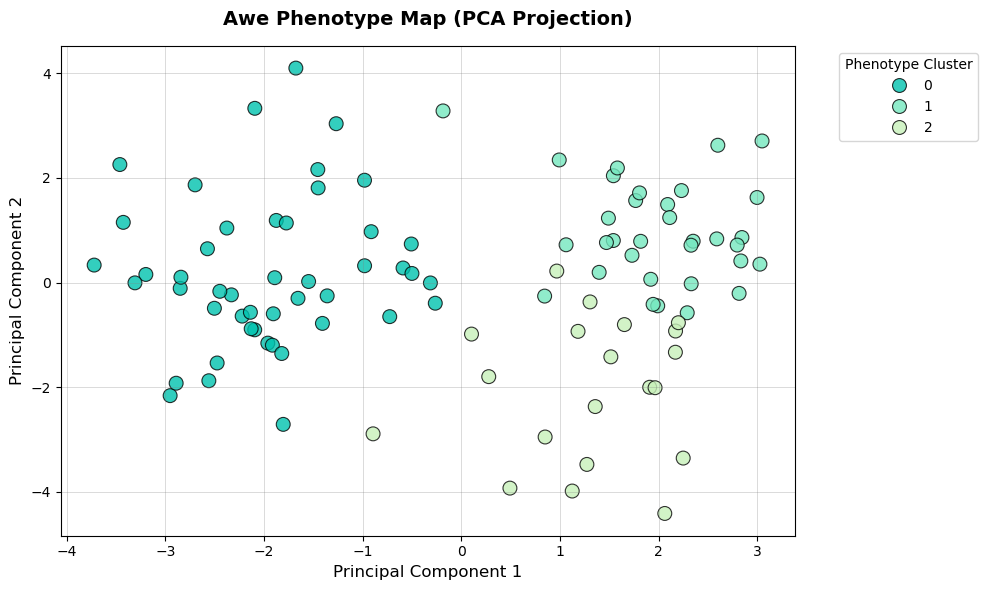

In [82]:
#7. Target Link: How does each phenotype related to the SPARK trait? 
#assuming 'chills_ability' is coded as 0/1
spark_link_df = (
    mindfulness_df
    .groupby('cluster')['chills_ability']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

# Round percentages
spark_link_df = spark_link_df.round(2)

# Reset index for cleaner table formatting
spark_link_df = spark_link_df.reset_index()

print("\n--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---")
display(spark_link_df)

#8. Visualize the Phenotype Map
pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=mindfulness_df, x='pca_1', y='pca_2', hue='cluster', palette=pheno_colors, edgecolor='black', alpha=0.8, s=100)

# Titles - bolded, fontsize 14
plt.title('Awe Phenotype Map (PCA Projection)', fontsize=14, fontweight='bold', pad=15)

# Axis Labels - fontsize 12
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Grid Lines - color grey, weight 0.1-0.4
# Note: linewidth (lw) set to 0.4 for a subtle but visible look
plt.grid(True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)

# Move legend to the side so it doesn't block the grid
plt.legend(title='Phenotype Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Religiosity & Self Transendence Construct

In [94]:
religiosity_df = df.copy()

features = ['age_range', 'env_growth', 'worldview', 'activity_primary', 
    'gender_assigned', 'edu_level', 'income_bracket', 'socioec_status', 
'trigger_interpersonal_4',
'trigger_interpersonal_5',
'trigger_spiritual_1',
'trigger_spiritual_2',
'trigger_spiritual_3',
'trigger_spiritual_4']

#one hot encode the text categories
X_encoded = pd.get_dummies(religiosity_df[features], drop_first=True)

#2. Impute (look at 5 nearest neighbors by default)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_encoded)

#3. Scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#4. Building the cluster model
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
religiosity_df['cluster'] = kmeans.fit_predict(X_scaled)

#5. Dimensionality reduction for visualization
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
religiosity_df['pca_1'] = pca_data[:,0]
religiosity_df['pca_2'] = pca_data[:,1]

#6. Analysis: Identifying the Awe phenotpyes 
phenotype_profiles = religiosity_df.groupby('cluster')[features].agg(lambda x: x.mode()[0])
phenotype_profiles = (
    religiosity_df
    .groupby('cluster')[features]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)
phenotype_profiles.set_index('cluster', inplace=True)

print("--- Phenotype Profiles (Dominant Traits) ---")
display(phenotype_profiles.T)

--- Phenotype Profiles (Dominant Traits) ---


cluster,0,1,2
age_range,19-21,19-21,25-30
env_growth,Suburban,Suburban,Suburban
worldview,Religious/Theistic,Atheist/Naturalist,Agnostic/Secular
activity_primary,Studying,Studying,Work
gender_assigned,Female,Female,Female
edu_level,High school Diploma/GED,High school Diploma/GED,Undergraduate
income_bracket,0-50K,0-50K,0-50K
socioec_status,Middle class,Upper middle class,Low middle class
trigger_interpersonal_4,4,3,4
trigger_interpersonal_5,4,3,4



--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---


chills_ability,cluster,0.0,1.0
0,0,62.96,37.04
1,1,75.00,25.00
2,2,66.67,33.33


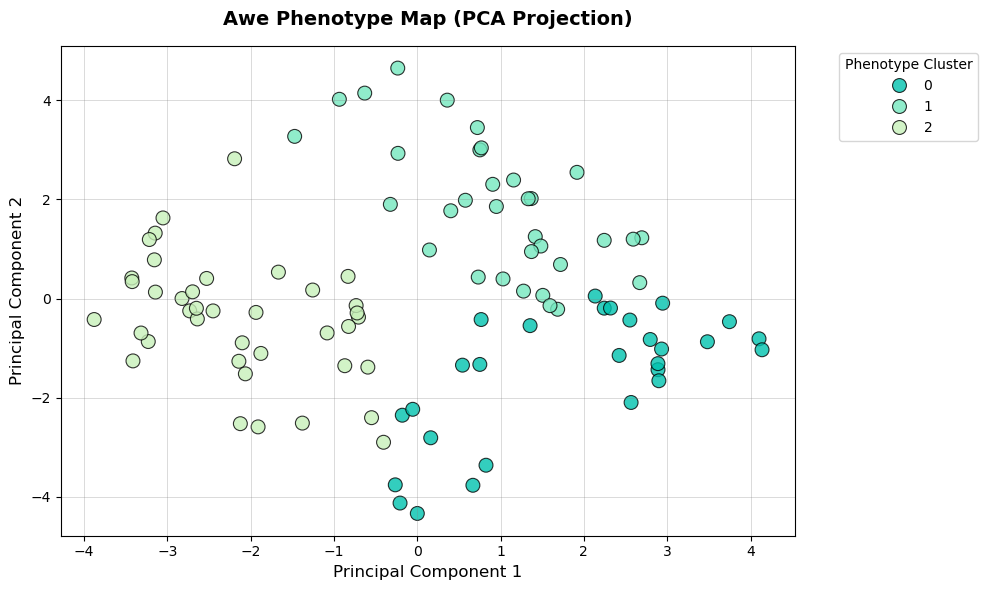

In [96]:
#7. Target Link: How does each phenotype related to the SPARK trait? 
#assuming 'chills_ability' is coded as 0/1
spark_link_df = (
    religiosity_df
    .groupby('cluster')['chills_ability']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

# Round percentages
spark_link_df = spark_link_df.round(2)

# Reset index for cleaner table formatting
spark_link_df = spark_link_df.reset_index()

print("\n--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---")
display(spark_link_df)

#8. Visualize the Phenotype Map
pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=religiosity_df, x='pca_1', y='pca_2', hue='cluster', palette=pheno_colors, edgecolor='black', alpha=0.8, s=100)

# Titles - bolded, fontsize 14
plt.title('Awe Phenotype Map (PCA Projection)', fontsize=14, fontweight='bold', pad=15)

# Axis Labels - fontsize 12
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Grid Lines - color grey, weight 0.1-0.4
# Note: linewidth (lw) set to 0.4 for a subtle but visible look
plt.grid(True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)

# Move legend to the side so it doesn't block the grid
plt.legend(title='Phenotype Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Ego Strength and Resilience Construct

In [98]:
ego_strength_df = df.copy()

features = ['age_range', 'env_growth', 'worldview', 'activity_primary', 
    'gender_assigned', 'edu_level', 'income_bracket', 'socioec_status', 
'trigger_interpersonal_6',
'trigger_interpersonal_7',
'trigger_interpersonal_8']

#one hot encode the text categories
X_encoded = pd.get_dummies(ego_strength_df[features], drop_first=True)

#2. Impute (look at 5 nearest neighbors by default)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_encoded)

#3. Scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#4. Building the cluster model
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
ego_strength_df['cluster'] = kmeans.fit_predict(X_scaled)

#5. Dimensionality reduction for visualization
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
ego_strength_df['pca_1'] = pca_data[:,0]
ego_strength_df['pca_2'] = pca_data[:,1]

#6. Analysis: Identifying the Awe phenotpyes 
phenotype_profiles = ego_strength_df.groupby('cluster')[features].agg(lambda x: x.mode()[0])
phenotype_profiles = (
    ego_strength_df
    .groupby('cluster')[features]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)
phenotype_profiles.set_index('cluster', inplace=True)

print("--- Phenotype Profiles (Dominant Traits) ---")
display(phenotype_profiles.T)

--- Phenotype Profiles (Dominant Traits) ---


cluster,0,1,2
age_range,25-30,19-21,22-24
env_growth,Suburban,Suburban,Suburban
worldview,Spiritual but not Religious,Religious/Theistic,Agnostic/Secular
activity_primary,Work,Studying,Work
gender_assigned,Female,Female,Female
edu_level,Undergraduate,High school Diploma/GED,Graduate
income_bracket,0-50K,0-50K,70-90K
socioec_status,Middle class,Upper middle class,Low middle class
trigger_interpersonal_6,4,4,4
trigger_interpersonal_7,1,2,2



--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---


chills_ability,cluster,0.0,1.0
0,0,61.76,38.24
1,1,72.92,27.08
2,2,68.75,31.25


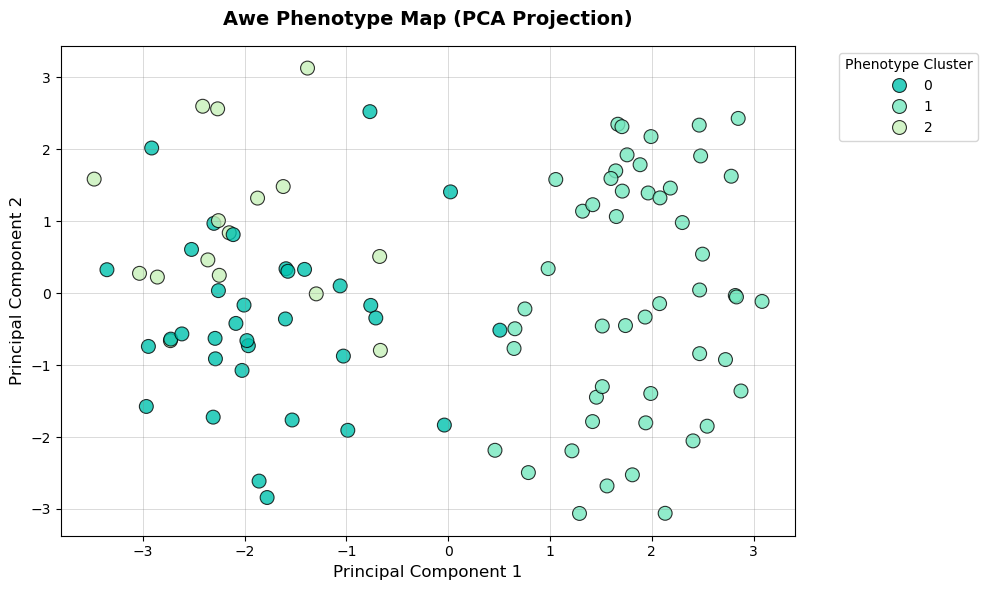

In [100]:
#7. Target Link: How does each phenotype related to the SPARK trait? 
#assuming 'chills_ability' is coded as 0/1
spark_link_df = (
    ego_strength_df
    .groupby('cluster')['chills_ability']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

# Round percentages
spark_link_df = spark_link_df.round(2)

# Reset index for cleaner table formatting
spark_link_df = spark_link_df.reset_index()

print("\n--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---")
display(spark_link_df)

#8. Visualize the Phenotype Map
pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=ego_strength_df, x='pca_1', y='pca_2', hue='cluster', palette=pheno_colors, edgecolor='black', alpha=0.8, s=100)

# Titles - bolded, fontsize 14
plt.title('Awe Phenotype Map (PCA Projection)', fontsize=14, fontweight='bold', pad=15)

# Axis Labels - fontsize 12
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Grid Lines - color grey, weight 0.1-0.4
# Note: linewidth (lw) set to 0.4 for a subtle but visible look
plt.grid(True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)

# Move legend to the side so it doesn't block the grid
plt.legend(title='Phenotype Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Belief Strength Ranking Construct

In [103]:
belief_df = df.copy()

features = ['age_range', 'env_growth', 'worldview', 'activity_primary', 
    'gender_assigned', 'edu_level', 'income_bracket', 'socioec_status', 
'trigger_interpersonal_9',
'trigger_spiritual_5',
'trigger_spiritual_6',
'trigger_spiritual_7',
'trigger_spiritual_8']

#one hot encode the text categories
X_encoded = pd.get_dummies(belief_df[features], drop_first=True)

#2. Impute (look at 5 nearest neighbors by default)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_encoded)

#3. Scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#4. Building the cluster model
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
belief_df['cluster'] = kmeans.fit_predict(X_scaled)

#5. Dimensionality reduction for visualization
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
belief_df['pca_1'] = pca_data[:,0]
belief_df['pca_2'] = pca_data[:,1]

#6. Analysis: Identifying the Awe phenotpyes 
phenotype_profiles = belief_df.groupby('cluster')[features].agg(lambda x: x.mode()[0])
phenotype_profiles = (
    belief_df
    .groupby('cluster')[features]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)
phenotype_profiles.set_index('cluster', inplace=True)

print("--- Phenotype Profiles (Dominant Traits) ---")
display(phenotype_profiles.T)

--- Phenotype Profiles (Dominant Traits) ---


cluster,0,1,2
age_range,25-30,19-21,25-30
env_growth,Suburban,Suburban,Suburban
worldview,Agnostic/Secular,Religious/Theistic,Spiritual but not Religious
activity_primary,Work,Studying,Work
gender_assigned,Female,Female,Female
edu_level,Undergraduate,High school Diploma/GED,Undergraduate
income_bracket,0-50K,0-50K,0-50K
socioec_status,Low middle class,Upper middle class,Low middle class
trigger_interpersonal_9,3.0,3.0,4.0
trigger_spiritual_5,1,1,3



--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---


chills_ability,cluster,0.0,1.0
0,0,55.56,44.44
1,1,77.27,22.73
2,2,66.67,33.33


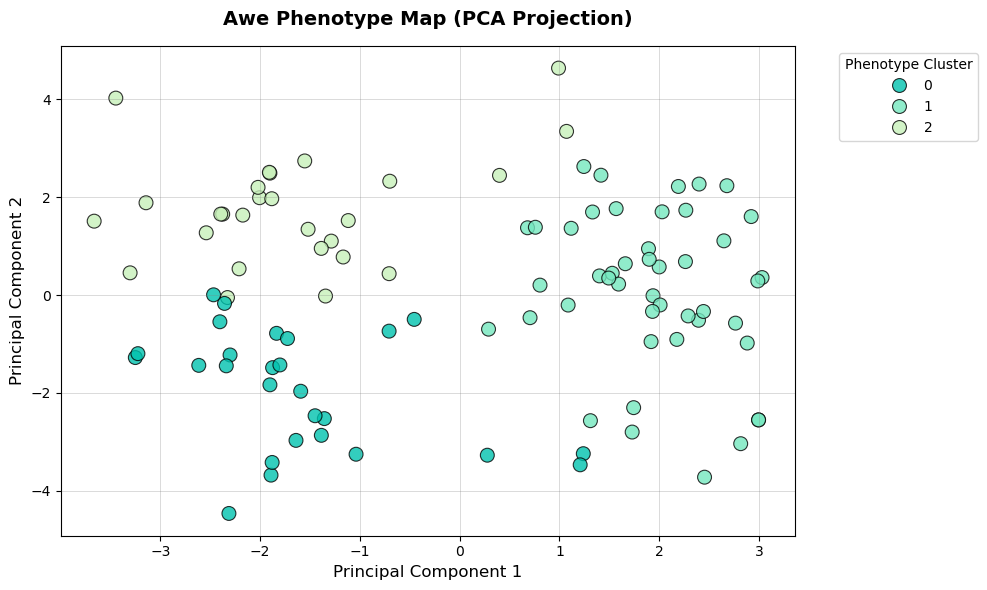

In [105]:
#7. Target Link: How does each phenotype related to the SPARK trait? 
#assuming 'chills_ability' is coded as 0/1
spark_link_df = (
    belief_df
    .groupby('cluster')['chills_ability']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

# Round percentages
spark_link_df = spark_link_df.round(2)

# Reset index for cleaner table formatting
spark_link_df = spark_link_df.reset_index()

print("\n--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---")
display(spark_link_df)

#8. Visualize the Phenotype Map
pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=belief_df, x='pca_1', y='pca_2', hue='cluster', palette=pheno_colors, edgecolor='black', alpha=0.8, s=100)

# Titles - bolded, fontsize 14
plt.title('Awe Phenotype Map (PCA Projection)', fontsize=14, fontweight='bold', pad=15)

# Axis Labels - fontsize 12
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Grid Lines - color grey, weight 0.1-0.4
# Note: linewidth (lw) set to 0.4 for a subtle but visible look
plt.grid(True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)

# Move legend to the side so it doesn't block the grid
plt.legend(title='Phenotype Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Physical Sensations Construct

In [110]:
physical_df = df.copy()

features = ['age_range', 'env_growth', 'worldview', 'activity_primary', 
    'gender_assigned', 'edu_level', 'income_bracket', 'socioec_status', 
'trigger_phys_10',
'trigger_phys_11',
'trigger_phys_12',
'trigger_phys_13']

#one hot encode the text categories
X_encoded = pd.get_dummies(physical_df[features], drop_first=True)

#2. Impute (look at 5 nearest neighbors by default)
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_encoded)

#3. Scale 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#4. Building the cluster model
kmeans = KMeans(n_clusters = 3, random_state=42, n_init=10)
physical_df['cluster'] = kmeans.fit_predict(X_scaled)

#5. Dimensionality reduction for visualization
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
physical_df['pca_1'] = pca_data[:,0]
physical_df['pca_2'] = pca_data[:,1]

#6. Analysis: Identifying the Awe phenotpyes 
phenotype_profiles = physical_df.groupby('cluster')[features].agg(lambda x: x.mode()[0])
phenotype_profiles = (
    physical_df
    .groupby('cluster')[features]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
)
phenotype_profiles.set_index('cluster', inplace=True)

print("--- Phenotype Profiles (Dominant Traits) ---")
display(phenotype_profiles.T)

--- Phenotype Profiles (Dominant Traits) ---


cluster,0,1,2
age_range,25-30,19-21,22-24
env_growth,Suburban,Suburban,Suburban
worldview,Spiritual but not Religious,Religious/Theistic,Agnostic/Secular
activity_primary,Work,Studying,Work
gender_assigned,Female,Female,Female
edu_level,Undergraduate,High school Diploma/GED,Graduate
income_bracket,0-50K,0-50K,0-50K
socioec_status,Low middle class,Upper middle class,Middle class
trigger_phys_10,3.0,3.0,3.0
trigger_phys_11,1.0,2.0,3.0



--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---


chills_ability,cluster,0.0,1.0
0,0,66.67,33.33
1,1,70.83,29.17
2,2,65.38,34.62


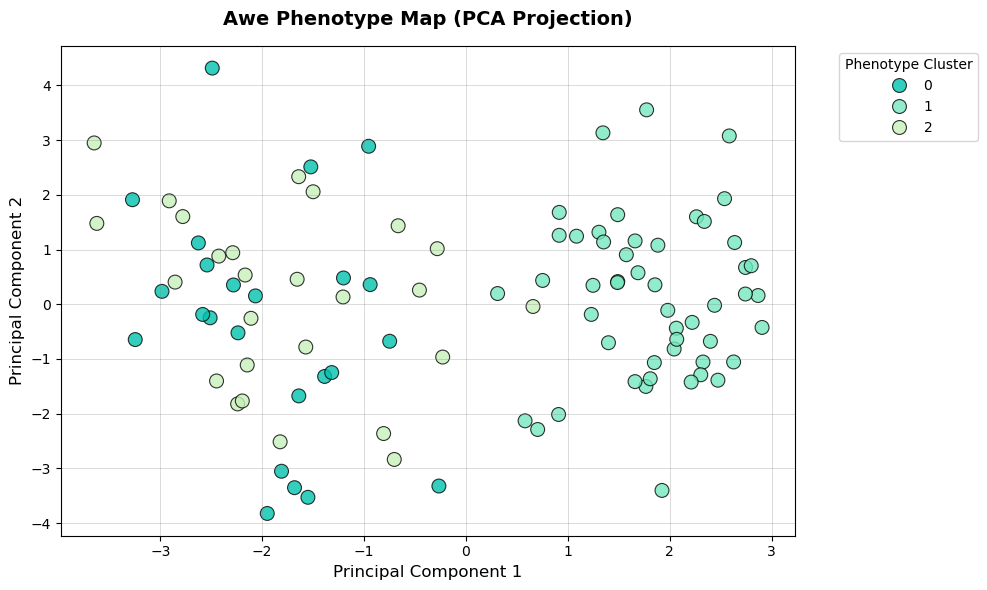

In [112]:
#7. Target Link: How does each phenotype related to the SPARK trait? 
#assuming 'chills_ability' is coded as 0/1
spark_link_df = (
    physical_df
    .groupby('cluster')['chills_ability']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

# Round percentages
spark_link_df = spark_link_df.round(2)

# Reset index for cleaner table formatting
spark_link_df = spark_link_df.reset_index()

print("\n--- SPARK Trait (chills_ability) Distribution per Cluster (%) ---")
display(spark_link_df)

#8. Visualize the Phenotype Map
pheno_colors = ["#00C2AE", "#74E8BF", "#C7F0B9"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=physical_df, x='pca_1', y='pca_2', hue='cluster', palette=pheno_colors, edgecolor='black', alpha=0.8, s=100)

# Titles - bolded, fontsize 14
plt.title('Awe Phenotype Map (PCA Projection)', fontsize=14, fontweight='bold', pad=15)

# Axis Labels - fontsize 12
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Grid Lines - color grey, weight 0.1-0.4
# Note: linewidth (lw) set to 0.4 for a subtle but visible look
plt.grid(True, color='grey', linestyle='-', linewidth=0.4, alpha=0.5)

# Move legend to the side so it doesn't block the grid
plt.legend(title='Phenotype Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()